<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/aliya's-LR/DMW_GA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVALUATION AND METRICS

In [ ]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability for ROC-AUC

# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

# Get feature importance (coefficients)
feature_names = X.columns
coefficients = lr_model.coef_[0]

# Create a Series for feature importance (absolute values)
feature_importance_series = pd.Series(np.abs(coefficients), index=feature_names)
top_features = feature_importance_series.nlargest(5)

# Format the top features into a string
top_features_str = "\n".join([f"- {name}: {value:.4f}" for name, value in top_features.items()])

# Print Core Metrics
print("\n" + "="*40)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("="*40)
print(f"Accuracy:  {metric_accuracy:.4f}")
print(f"Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"F1-Score:  {metric_f1:.4f} (Balance of Precision/Recall)")
print(f"ROC-AUC:   {metric_auc:.4f}")
print("\nTop 5 Most Important Features:")
print(top_features_str)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))



MODEL EVALUATION

LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy:   0.8265 (82.65%)
Precision:  0.8571 (85.71%) - How many predicted defaults are actual defaults
Recall:     0.7097 (70.97%) - How many actual defaults we caught
F1-Score:   0.7765 (Harmonic mean of Precision & Recall)
ROC-AUC:    0.8972 (Area under ROC curve)

--------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

    Paid (0)       0.81      0.91      0.86       126
 Default (1)       0.86      0.71      0.78        93

    accuracy                           0.83       219
   macro avg       0.83      0.81      0.82       219
weighted avg       0.83      0.83      0.82       219


--------------------------------------------------
TOP 5 MOST IMPORTANT FEATURES
--------------------------------------------------
     Feature  Coefficient  Abs_Coefficient
   DTI_Ratio     1.951612         1.951612
  

# VISUALISATIONS


GENERATING VISUALIZATIONS


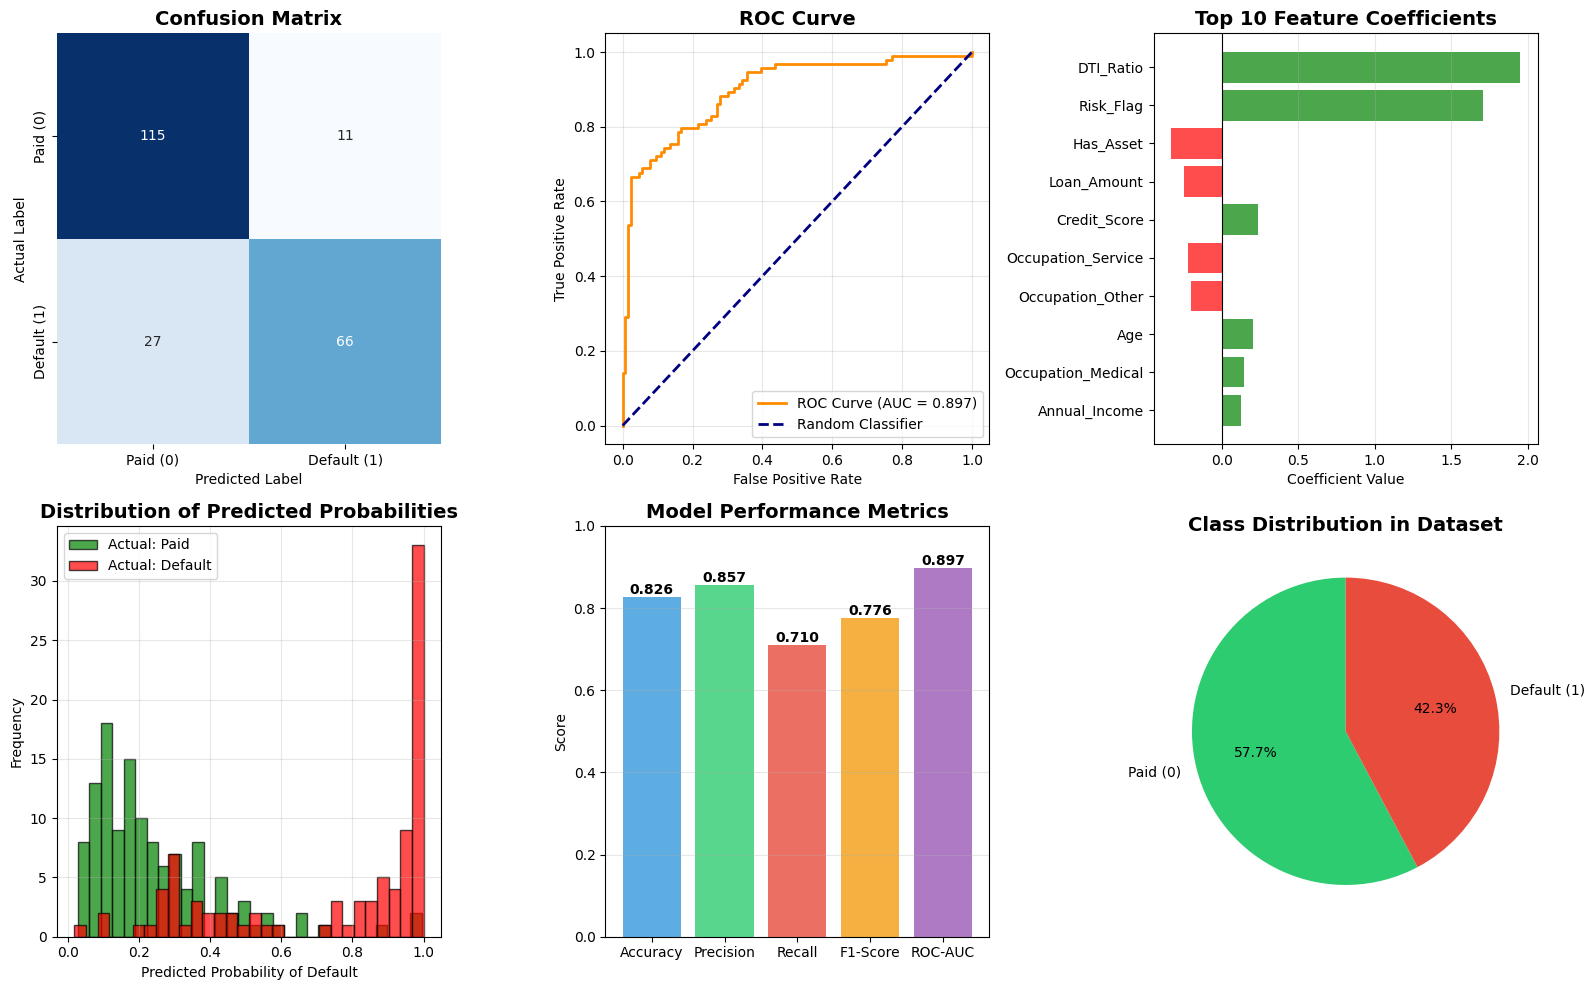

✅ Visualizations Generated.


In [ ]:
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# Create a comprehensive visualization
fig = plt.figure(figsize=(16, 10))

# 5.1 Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('Actual Label')
ax1.set_xticklabels(['Paid (0)', 'Default (1)'])
ax1.set_yticklabels(['Paid (0)', 'Default (1)'])

# 5.2 ROC Curve
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {metric_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 5.3 Feature Importance (Top 10)
ax3 = plt.subplot(2, 3, 3)
top_10_features = feature_importance_df.head(10)
colors = ['red' if x < 0 else 'green' for x in top_10_features['Coefficient']]
ax3.barh(range(len(top_10_features)), top_10_features['Coefficient'], color=colors, alpha=0.7)
ax3.set_yticks(range(len(top_10_features)))
ax3.set_yticklabels(top_10_features['Feature'])
ax3.set_xlabel('Coefficient Value')
ax3.set_title('Top 10 Feature Coefficients', fontsize=14, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# 5.4 Prediction Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(y_prob[y_test == 0], bins=30, alpha=0.7, label='Actual: Paid', color='green', edgecolor='black')
ax4.hist(y_prob[y_test == 1], bins=30, alpha=0.7, label='Actual: Default', color='red', edgecolor='black')
ax4.set_xlabel('Predicted Probability of Default')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5.5 Performance Metrics Bar Chart
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [metric_accuracy, metric_precision, metric_recall, metric_f1, metric_auc]
bars = ax5.bar(metrics_names, metrics_values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], alpha=0.8)
ax5.set_ylabel('Score')
ax5.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.3f}',
             ha='center', va='bottom', fontweight='bold')

# 5.6 Class Distribution
ax6 = plt.subplot(2, 3, 6)
class_counts = y.value_counts()
ax6.pie(class_counts.values, labels=['Paid (0)', 'Default (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
ax6.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizations Generated.")